In [1]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [4]:
#Read All Well Files
well1 = pd.read_csv("well 1.csv")
well2 = pd.read_csv("well 2.csv")
well3 = pd.read_csv("well 3.csv")
well4 = pd.read_csv("well 4.csv")
well5 = pd.read_csv("well 5.csv")
well6 = pd.read_csv("well 6.csv")
well7 = pd.read_csv("well 7.csv")
well8 = pd.read_csv("well 8.csv")

In [5]:
#Check Dataset Structure
well1.head()
well1.info()
well1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1387 entries, 0 to 1386
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DEPTH        1387 non-null   float64
 1   GR           1387 non-null   float64
 2   RHOB         1387 non-null   float64
 3   Vp           1387 non-null   float64
 4   Vsh          1387 non-null   float64
 5   Caliper      1387 non-null   float64
 6   Porosity     1387 non-null   float64
 7   Resistivity  1387 non-null   float64
 8   Stress       1387 non-null   float64
 9   PP           1387 non-null   float64
dtypes: float64(10)
memory usage: 108.5 KB


,DEPTH,GR,RHOB,Vp,Vsh,Caliper,Porosity,Resistivity,Stress,PP
count,1387.000000,1387.000000,1387.000000,1387.000000,1387.000000,1387.000000,1387.000000,1387.000000,1.387000e+03,1387.000000
mean,127.615600,87.901598,1.771314,1.531187,0.579755,10.203106,61.652231,0.865095,2.259713e+06,1775.104542
std,61.041797,9.528609,0.122574,0.030551,0.154733,0.450497,5.481693,0.091293,1.126686e+06,104.597326
min,22.002400,49.009600,1.443800,1.456400,-0.112995,9.417900,49.810100,0.692600,3.127835e+05,1609.000000
25%,74.809000,84.647800,1.709100,1.505500,0.514748,9.859650,57.624400,0.811700,1.335455e+06,1684.000000
50%,127.615600,88.817300,1.793800,1.529500,0.588950,10.137400,61.182000,0.857400,2.364853e+06,1773.000000
75%,180.422200,92.858700,1.860300,1.553900,0.659965,10.466350,65.763500,0.897550,3.115191e+06,1866.000000
max,233.228800,106.834800,2.023100,1.618800,0.905575,11.794200,77.645200,1.396800,4.494676e+06,1966.000000


In [7]:
#Combine All Wells
data = pd.concat([
    well1,
    well2,
    well3,
    well4,
    well5,
    well6,
    well7,
    well8
], ignore_index=True)

data.shape

(11494, 10)

In [8]:
#Check Missing Values
data.isnull().sum()

,0
DEPTH,0
GR,0
RHOB,0
Vp,0
Vsh,0
Caliper,0
Porosity,0
Resistivity,0
Stress,0
PP,0


In [9]:
#Handle Missing Values
data = data.dropna()
data.fillna(data.mean(), inplace=True)

In [10]:
#Remove Duplicate Records
data.duplicated().sum()
data = data.drop_duplicates()

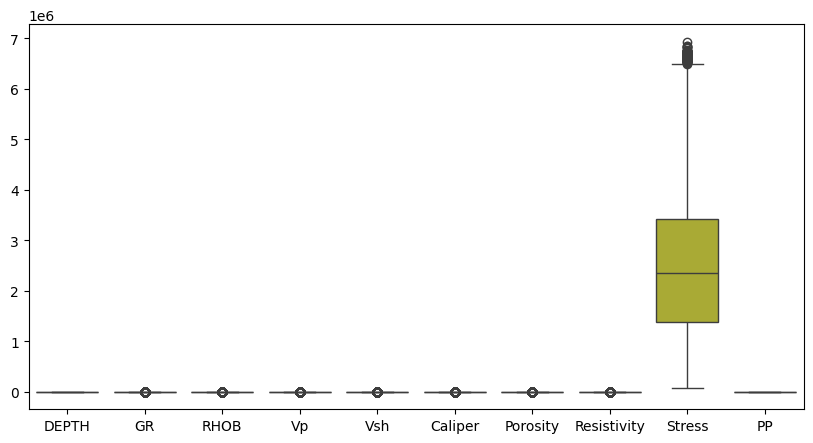

In [11]:
#Outlier Detection
plt.figure(figsize=(10,5))
sns.boxplot(data=data)
plt.show()

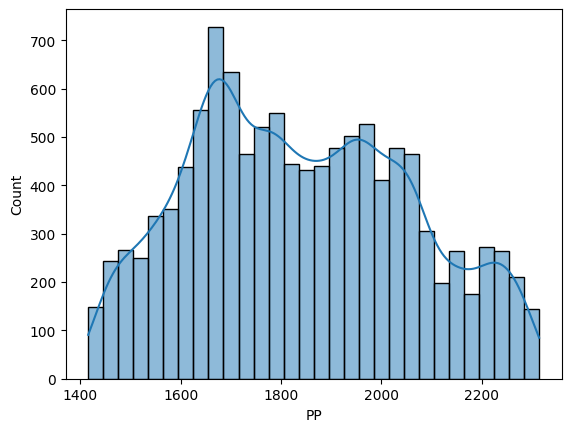

In [13]:
#Exploratory Data Analysis
sns.histplot(data["PP"], kde=True)
plt.show()

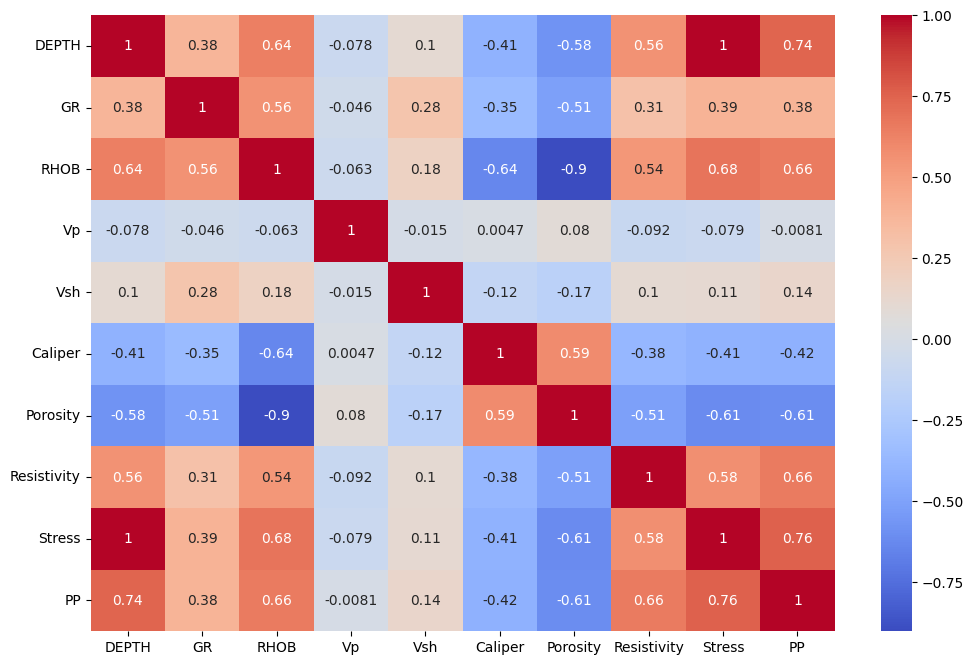

In [14]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

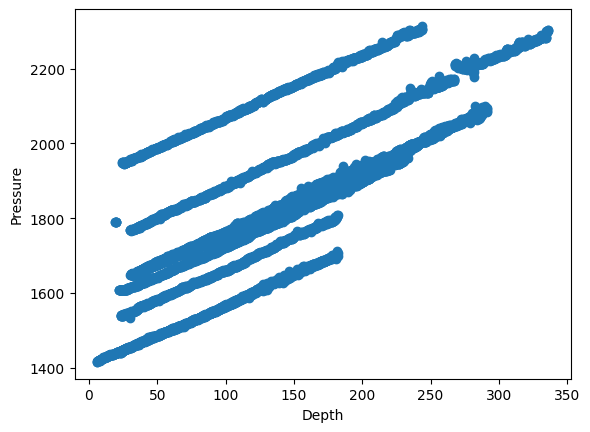

In [16]:
#Depth vs Pressure
plt.scatter(
    data["DEPTH"],
    data["PP"]
)

plt.xlabel("Depth")
plt.ylabel("Pressure")

plt.show()

In [19]:
#Feature Selection
X = data[
[
'DEPTH',
'GR',
'RHOB',
'Porosity', # Replaced 'NPHI' with 'Porosity'
'Vp',       # Replaced 'DT' with 'Vp'
'Resistivity' # Replaced 'RES' with 'Resistivity'
]
]

y = data['PP']

In [20]:
#Train-Test Split
#80% Training and 20% Testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Data Modelling**

In [21]:
#Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(
    y_test,
    pred_lr
)

r2_lr = r2_score(
    y_test,
    pred_lr
)

print(mae_lr)
print(r2_lr)

95.39462066097116
0.6517556631596334


In [23]:
#Random Forest

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)


mae_rf = mean_absolute_error(
    y_test,
    pred_rf
)

r2_rf = r2_score(
    y_test,
    pred_rf
)

print(mae_rf)
print(r2_rf)

17.452982582427126
0.9738213462112209


In [25]:
#Gradient Boosting

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(
    y_test,
    pred_gb
)

r2_gb = r2_score(
    y_test,
    pred_gb
)
print(mae_gb)
print(r2_gb)

55.88673608132767
0.8838134422882011


In [27]:
#Calculate RMSE(Root Mean Square Error)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_rf
    )
)
rmse

np.float64(35.177573225133365)

In [28]:
#Create Comparison Table

results = pd.DataFrame({
'Model':['Linear','Random Forest','Gradient Boosting'],
'MAE':[mae_lr,mae_rf,mae_gb],
'R2':[r2_lr,r2_rf,r2_gb]
})

print(results)

               Model        MAE        R2
0             Linear  95.394621  0.651756
1      Random Forest  17.452983  0.973821
2  Gradient Boosting  55.886736  0.883813


In [29]:
#Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores.mean())

-0.030259339064449442


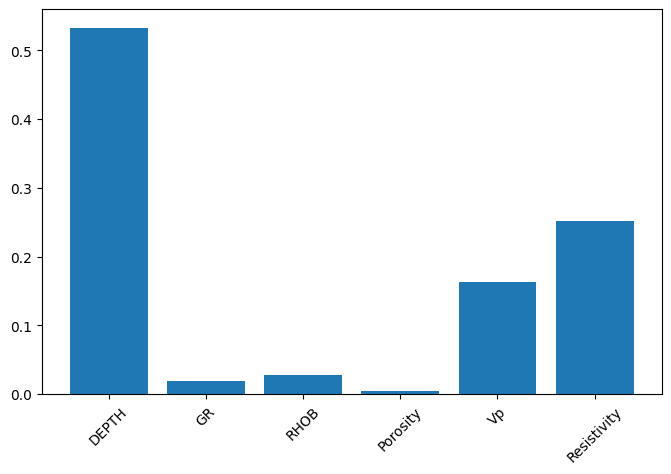

In [31]:
#Feature Importance

importance = rf.feature_importances_

plt.figure(figsize=(8,5))

plt.bar(
    X.columns,
    importance
)

plt.xticks(rotation=45)

plt.show()

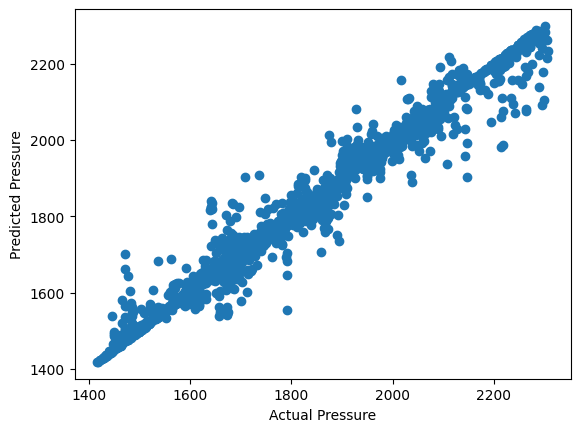

In [32]:
#Actual vs Predicted Plot

plt.scatter(
    y_test,
    pred_rf
)

plt.xlabel("Actual Pressure")
plt.ylabel("Predicted Pressure")

plt.show()

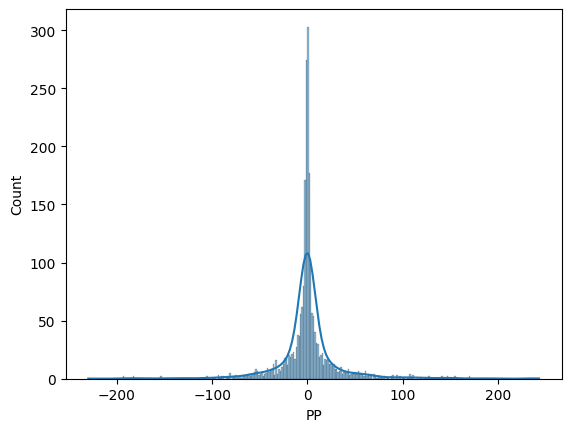

In [33]:
#Residual Analysis

residuals = y_test - pred_rf

sns.histplot(
    residuals,
    kde=True
)

plt.show()

In [34]:
#Save Best Model

import joblib

joblib.dump(
    rf,
    "PorePressureModel.pkl"
)

['PorePressureModel.pkl']

**Final Results Section-**

Three machine learning models were trained for pore pressure prediction. Random Forest Regressor achieved the highest performance with the lowest MAE and highest R² score. The model successfully learned relationships between well log parameters and pore pressure.

**Conclusion-**

The project successfully developed a machine learning-based pore pressure prediction system for the Krishna-Godavari Basin. Among the tested models, Random Forest Regressor showed the best predictive performance. The proposed approach can help drilling engineers estimate pore pressure more efficiently and reduce operational risks.